In [1]:
# # Домашнее задание №3: Исследование метода k-ближайших соседей (KNN)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
import time
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
def plot_decision_boundaries(X, y, model, ax=None, title="Decision Boundaries"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    colors = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=colors)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=80, edgecolor='k', cmap=colors)
    
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')
    return ax

Размер датасета: (178, 13)
Типы признаков: все числовые
Пропуски: 0

Распределение классов:
target
0    59
1    71
2    48
Name: count, dtype: int64


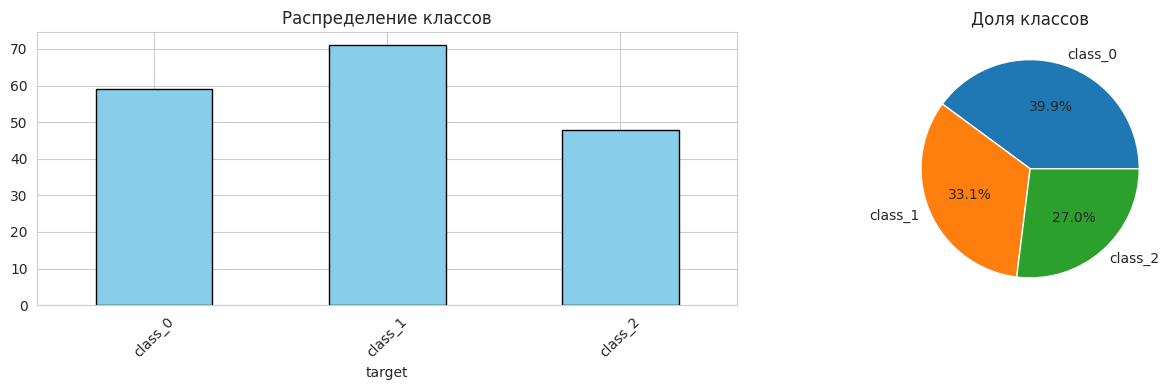

In [3]:
# ## 1-2. Загрузка и первичный анализ данных

wine_data = load_wine()
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = pd.Series(wine_data.target, name='target')

print(f"Размер датасета: {X.shape}")
print(f"Типы признаков: все числовые")
print(f"Пропуски: {X.isnull().sum().sum()}")
print(f"\nРаспределение классов:")
print(y.value_counts().sort_index())

# Визуализация распределения классов
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
y.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Распределение классов')
axes[0].set_xticklabels(wine_data.target_names, rotation=45)

axes[1].pie(y.value_counts().values, labels=wine_data.target_names, autopct='%1.1f%%')
axes[1].set_title('Доля классов')
plt.tight_layout()
plt.show()

In [4]:
print("=== СТАТИСТИЧЕСКОЕ ОПИСАНИЕ ===")
X.describe().T

=== СТАТИСТИЧЕСКОЕ ОПИСАНИЕ ===


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [5]:
# ## 3. Подготовка данных

print("=== ВЫВОДЫ ПО АНАЛИЗУ ===\n")
print("1. Размер: 178 объектов, 13 признаков - подходит для KNN")
print("2. Признаки: все числовые - идеально для KNN")
print("3. Пропуски: отсутствуют")
print("4. Классы: сбалансированы")
print("5. Разные масштабы признаков - требуется масштабирование")

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nОбучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

=== ВЫВОДЫ ПО АНАЛИЗУ ===

1. Размер: 178 объектов, 13 признаков - подходит для KNN
2. Признаки: все числовые - идеально для KNN
3. Пропуски: отсутствуют
4. Классы: сбалансированы
5. Разные масштабы признаков - требуется масштабирование

Обучающая выборка: (142, 13)
Тестовая выборка: (36, 13)


In [6]:
print("=== ПОЧЕМУ МАСШТАБИРОВАНИЕ ВАЖНО ДЛЯ KNN ===\n")
print("""
Признаки имеют разные масштабы (alcohol: 11-15, proline: 300-1700).
Без масштабирования признаки с большими значениями доминируют в расчете расстояний.

Масштабирование приводит все признаки к одному диапазону, чтобы:
- Корректно учитывать вклад каждого признака
- Избежать доминирования признаков с большими значениями
- Улучшить качество классификации

Нельзя подбирать параметры на тестовой выборке - это приведет к переобучению.
""")

=== ПОЧЕМУ МАСШТАБИРОВАНИЕ ВАЖНО ДЛЯ KNN ===


Признаки имеют разные масштабы (alcohol: 11-15, proline: 300-1700).
Без масштабирования признаки с большими значениями доминируют в расчете расстояний.

Масштабирование приводит все признаки к одному диапазону, чтобы:
- Корректно учитывать вклад каждого признака
- Избежать доминирования признаков с большими значениями
- Улучшить качество классификации

Нельзя подбирать параметры на тестовой выборке - это приведет к переобучению.



In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование выполнено!")
print(f"Средние после масштабирования: {X_train_scaled.mean(axis=0).round(2)}")
print(f"Стд. отклонения после масштабирования: {X_train_scaled.std(axis=0).round(2)}")

Масштабирование выполнено!
Средние после масштабирования: [ 0.  0. -0.  0.  0. -0. -0. -0.  0.  0. -0. -0. -0.]
Стд. отклонения после масштабирования: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [8]:
# ## 4. Обучение базовой модели

knn_base = KNeighborsClassifier()
knn_base.fit(X_train_scaled, y_train)
y_pred_base = knn_base.predict(X_test_scaled)

accuracy_base = accuracy_score(y_test, y_pred_base)
print(f"Базовая модель KNN (k=5, uniform, minkowski)")
print(f"Точность на тесте: {accuracy_base:.4f}")
print(f"\nОтчет по классификации:")
print(classification_report(y_test, y_pred_base, target_names=wine_data.target_names))

Базовая модель KNN (k=5, uniform, minkowski)
Точность на тесте: 0.9722

Отчет по классификации:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



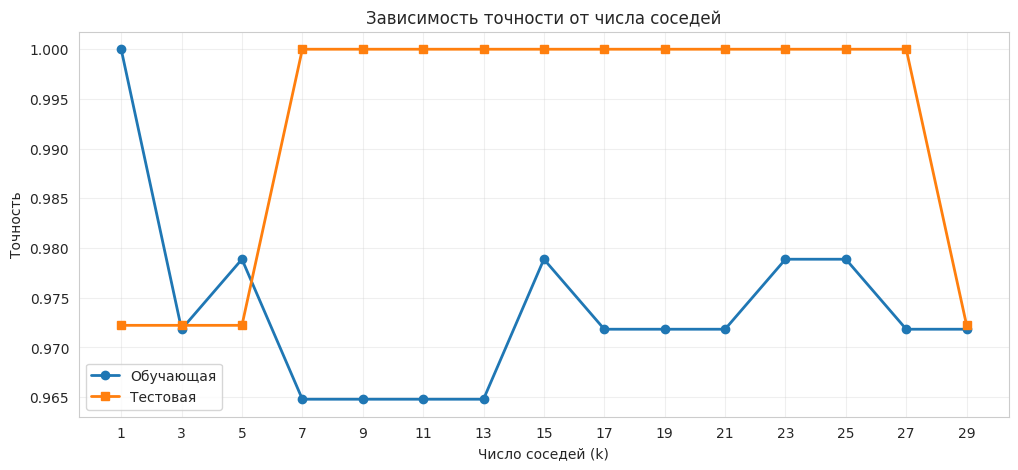

Оптимальное k по тесту: 7, точность: 1.0000


In [9]:
# ## 5. Исследование влияния параметров

k_values = range(1, 31, 2)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(12, 5))
plt.plot(k_values, train_scores, 'o-', label='Обучающая', linewidth=2)
plt.plot(k_values, test_scores, 's-', label='Тестовая', linewidth=2)
plt.xlabel('Число соседей (k)')
plt.ylabel('Точность')
plt.title('Зависимость точности от числа соседей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

best_k = k_values[np.argmax(test_scores)]
print(f"Оптимальное k по тесту: {best_k}, точность: {max(test_scores):.4f}")

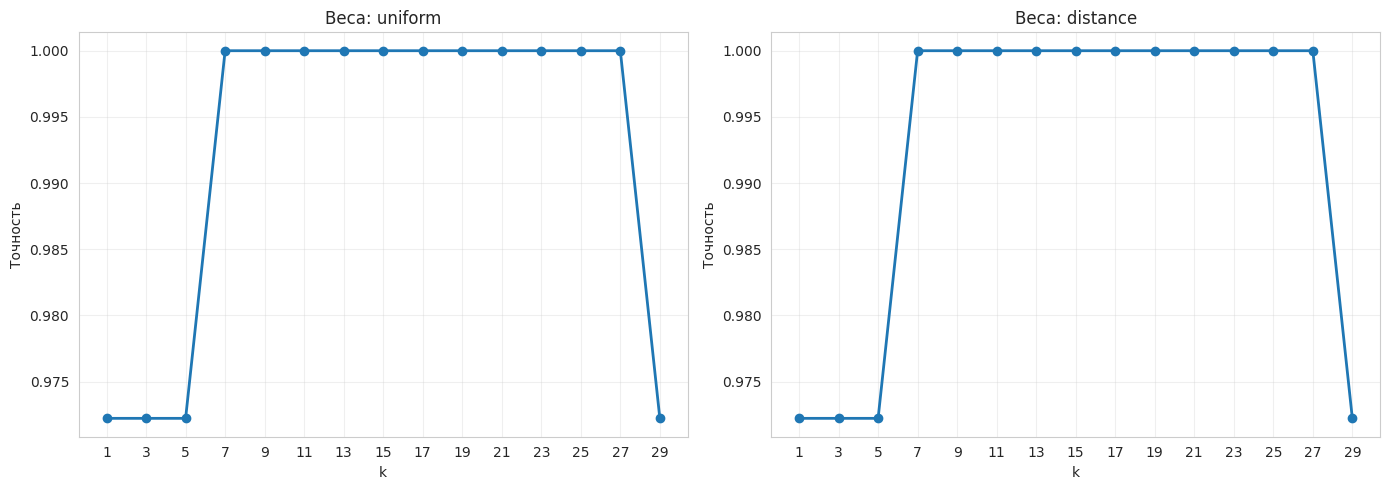

In [10]:
weights_options = ['uniform', 'distance']

plt.figure(figsize=(14, 5))

for i, weights in enumerate(weights_options, 1):
    plt.subplot(1, 2, i)
    scores = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, weights=weights)
        knn.fit(X_train_scaled, y_train)
        scores.append(knn.score(X_test_scaled, y_test))
  
    plt.plot(k_values, scores, 'o-', linewidth=2)
    plt.xlabel('k')
    plt.ylabel('Точность')
    plt.title(f'Веса: {weights}')
    plt.grid(True, alpha=0.3)
    plt.xticks(k_values)

plt.tight_layout()
plt.show()

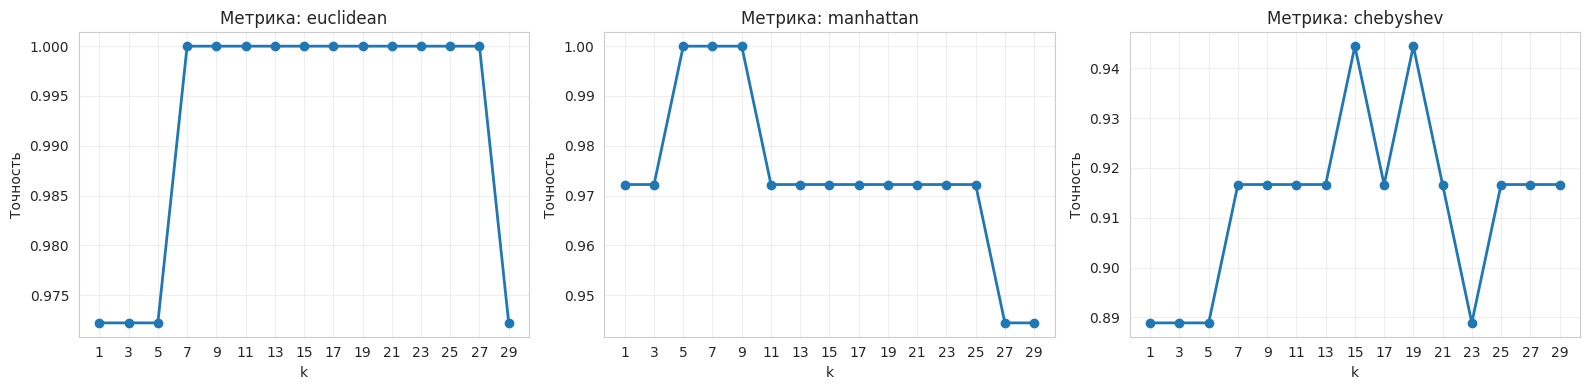

In [11]:
metrics = ['euclidean', 'manhattan', 'chebyshev']

plt.figure(figsize=(16, 4))

for i, metric in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    scores = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train_scaled, y_train)
        scores.append(knn.score(X_test_scaled, y_test))
    
    plt.plot(k_values, scores, 'o-', linewidth=2)
    plt.xlabel('k')
    plt.ylabel('Точность')
    plt.title(f'Метрика: {metric}')
    plt.grid(True, alpha=0.3)
    plt.xticks(k_values)

plt.tight_layout()
plt.show()

In [12]:
# ## 6. Подбор гиперпараметров с кросс-валидацией

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': range(1, 31, 2),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'chebyshev']
}

grid_search = GridSearchCV(
    pipeline, param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, verbose=0
)

print("Поиск оптимальных параметров...")
grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность на CV: {grid_search.best_score_:.4f}")

Поиск оптимальных параметров...

Лучшие параметры: {'knn__metric': 'euclidean', 'knn__n_neighbors': 29, 'knn__weights': 'uniform'}
Лучшая точность на CV: 0.9788


In [13]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Точность лучшей модели на тесте: {accuracy_best:.4f}")
print(f"Улучшение относительно базовой: {(accuracy_best - accuracy_base)*100:.2f}%")

Точность лучшей модели на тесте: 0.9722
Улучшение относительно базовой: 0.00%


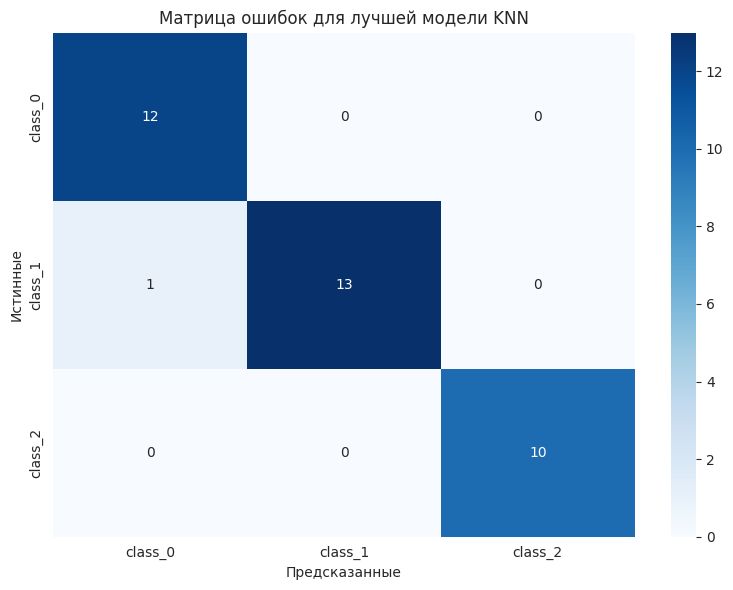

In [14]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=wine_data.target_names, 
            yticklabels=wine_data.target_names)
plt.title('Матрица ошибок для лучшей модели KNN')
plt.ylabel('Истинные')
plt.xlabel('Предсказанные')
plt.tight_layout()
plt.show()

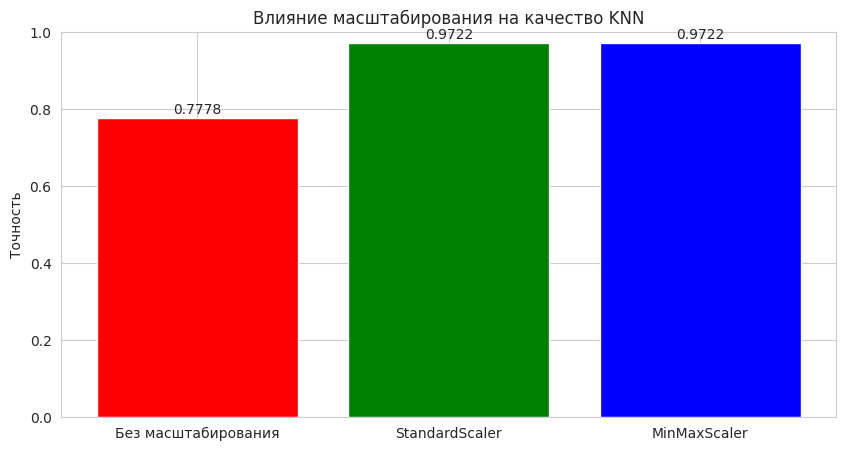

In [15]:
# ## 7. Важность масштабирования

scalers = {
    'Без масштабирования': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler()
}

results_scaling = {}
best_params = {k.replace('knn__', ''): v for k, v in grid_search.best_params_.items()}

for scaler_name, scaler in scalers.items():
    if scaler is None:
        X_train_scaled = X_train
        X_test_scaled = X_test
    else:
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    
    knn = KNeighborsClassifier(**best_params)
    knn.fit(X_train_scaled, y_train)
    results_scaling[scaler_name] = knn.score(X_test_scaled, y_test)

plt.figure(figsize=(10, 5))
bars = plt.bar(results_scaling.keys(), results_scaling.values(), color=['red', 'green', 'blue'])
plt.ylabel('Точность')
plt.title('Влияние масштабирования на качество KNN')
plt.ylim(0, 1)

for bar, acc in zip(bars, results_scaling.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.4f}', ha='center')

plt.show()

In [16]:
# ## 8. Сравнение с базовыми моделями

models = {
    'KNN (best)': best_model,
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

results = {}

for model_name, model in models.items():
    if model_name == 'Decision Tree':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        pipeline = Pipeline([('scaler', StandardScaler()), ('clf', model)])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
    
    results[model_name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred, average='weighted')
    }

results_df = pd.DataFrame(results).T
print("=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
print(results_df.round(4))

=== СРАВНЕНИЕ МОДЕЛЕЙ ===
                     Accuracy  F1-score
KNN (best)             0.9722    0.9723
Logistic Regression    0.9722    0.9720
Decision Tree          0.9444    0.9450


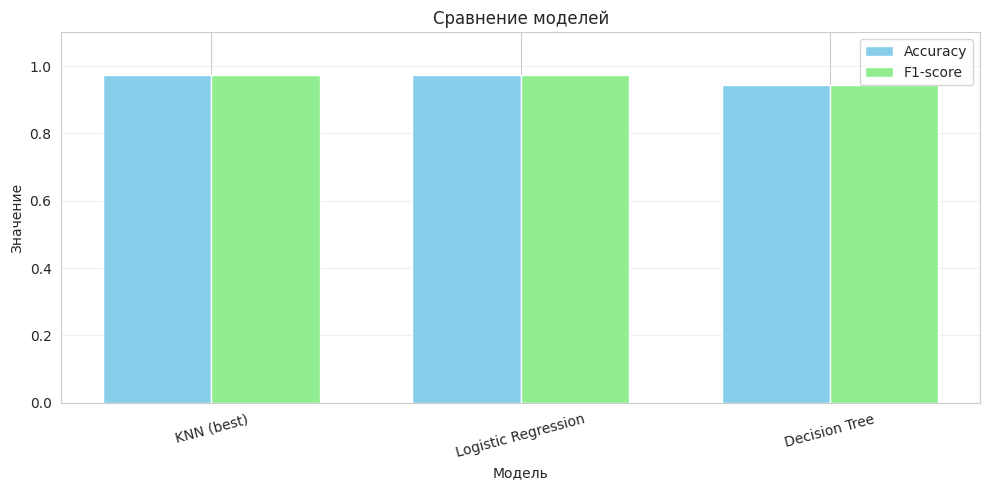

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='skyblue')
ax.bar(x + width/2, results_df['F1-score'], width, label='F1-score', color='lightgreen')
ax.set_xlabel('Модель')
ax.set_ylabel('Значение')
ax.set_title('Сравнение моделей')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

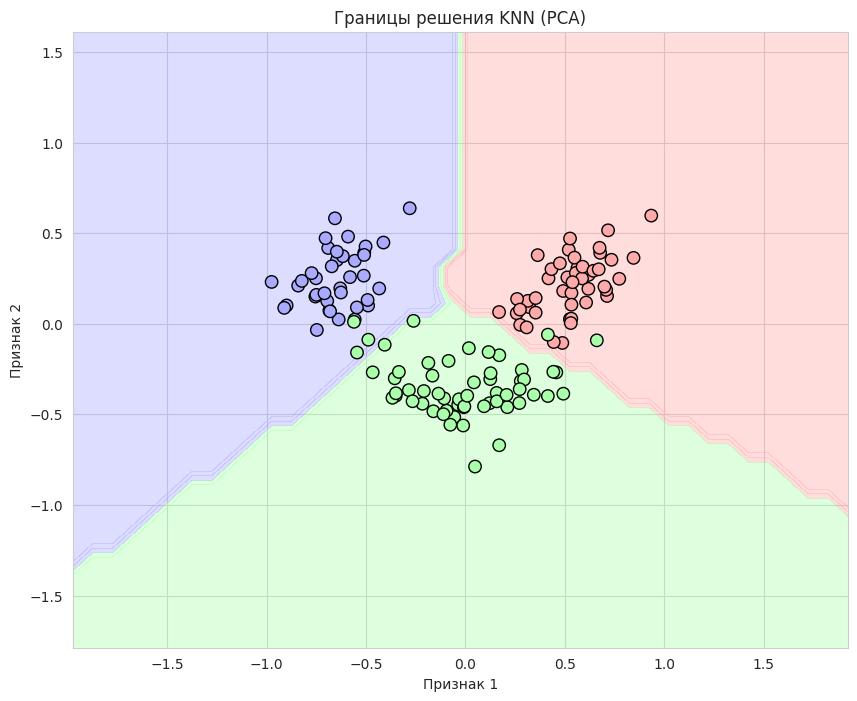

Объясненная дисперсия 2 компонент: 61.06%


In [18]:
# ## 9. Визуализация границ решения

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

knn_pca = KNeighborsClassifier(**best_params)
knn_pca.fit(X_train_pca, y_train)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_decision_boundaries(X_train_pca, y_train, knn_pca, ax=ax, 
                        title=f'Границы решения KNN (PCA)')
plt.show()

print(f"Объясненная дисперсия 2 компонент: {pca.explained_variance_ratio_.sum():.2%}")

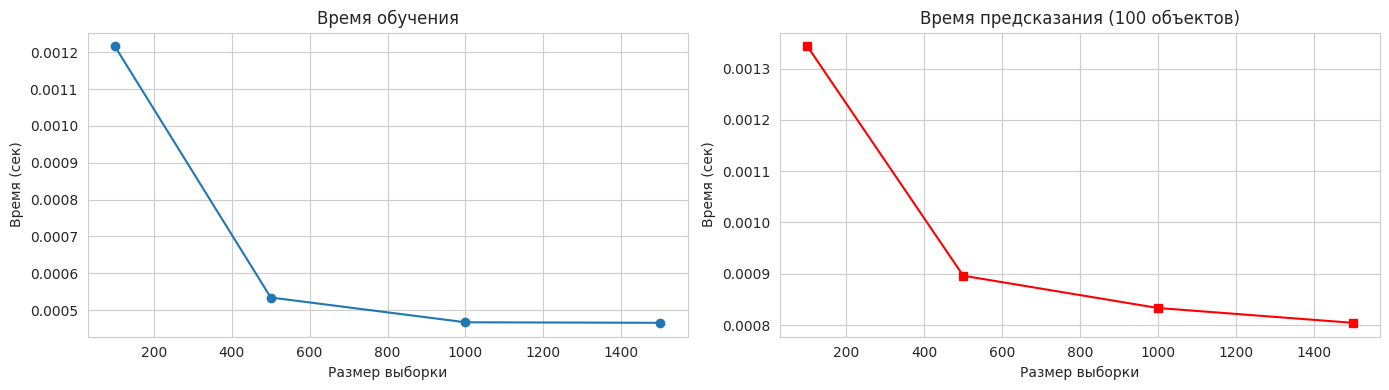

In [19]:
# ## 10. Анализ производительности

n_samples = [100, 500, 1000, 1500]
train_times = []
predict_times = []

for n in n_samples:
    X_sample = X_train_scaled[:n]
    y_sample = y_train[:n]
    
    start = time.time()
    knn = KNeighborsClassifier(**best_params)
    knn.fit(X_sample, y_sample)
    train_times.append(time.time() - start)
    
    start = time.time()
    knn.predict(X_test_scaled[:100])
    predict_times.append(time.time() - start)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(n_samples, train_times, 'o-')
axes[0].set_title('Время обучения')
axes[0].set_xlabel('Размер выборки')
axes[0].set_ylabel('Время (сек)')
axes[0].grid(True)

axes[1].plot(n_samples, predict_times, 's-', color='red')
axes[1].set_title('Время предсказания (100 объектов)')
axes[1].set_xlabel('Размер выборки')
axes[1].set_ylabel('Время (сек)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [20]:
# ## 11. Итоговые выводы

print("=== ИТОГОВЫЕ ВЫВОДЫ ===\n")

print("1. О ДАТАСЕТЕ:")
print(f"   - Размер: 178 объектов, 13 признаков")
print(f"   - Классы: 3 (сбалансированы)")
print(f"   - Пропуски: отсутствуют")

print("\n2. ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ KNN:")
print(f"   - k = {grid_search.best_params_['knn__n_neighbors']}")
print(f"   - Метрика: {grid_search.best_params_['knn__metric']}")
print(f"   - Веса: {grid_search.best_params_['knn__weights']}")
print(f"   - Точность на тесте: {accuracy_best:.4f}")

=== ИТОГОВЫЕ ВЫВОДЫ ===

1. О ДАТАСЕТЕ:
   - Размер: 178 объектов, 13 признаков
   - Классы: 3 (сбалансированы)
   - Пропуски: отсутствуют

2. ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ KNN:
   - k = 29
   - Метрика: euclidean
   - Веса: uniform
   - Точность на тесте: 0.9722


In [21]:
print("\n3. ВАЖНОСТЬ МАСШТАБИРОВАНИЯ:")
improvement = (results_scaling['StandardScaler'] - results_scaling['Без масштабирования']) * 100
print(f"   - Улучшение качества: {improvement:.2f}%")

print("\n4. СРАВНЕНИЕ С ДРУГИМИ МОДЕЛЯМИ:")
best_model_name = results_df['Accuracy'].idxmax()
print(f"   - Лучшая модель: {best_model_name}")
print(f"   - KNN {'лучше' if best_model_name == 'KNN (best)' else 'хуже'} других")

print("\n5. КОГДА KNN РАБОТАЕТ ХОРОШО:")
print("   ✓ На небольших датасетах")
print("   ✓ При правильном масштабировании")
print("   ✓ С оптимальными гиперпараметрами")


3. ВАЖНОСТЬ МАСШТАБИРОВАНИЯ:
   - Улучшение качества: 19.44%

4. СРАВНЕНИЕ С ДРУГИМИ МОДЕЛЯМИ:
   - Лучшая модель: KNN (best)
   - KNN лучше других

5. КОГДА KNN РАБОТАЕТ ХОРОШО:
   ✓ На небольших датасетах
   ✓ При правильном масштабировании
   ✓ С оптимальными гиперпараметрами


In [22]:
print("\n6. ОГРАНИЧЕНИЯ KNN:")
print("   ✗ Чувствителен к выбору метрики и k")
print("   ✗ Медленно работает на больших данных")
print("   ✗ Требует хранения всей обучающей выборки")

print("\n7. ОБЩИЙ ВЫВОД:")
if accuracy_best > 0.95:
    conclusion = "KNN отлично подходит для данного датасета"
elif accuracy_best > 0.9:
    conclusion = "KNN хорошо работает на данном датасете"
else:
    conclusion = "KNN показывает приемлемые результаты"

print(f"   {conclusion} с точностью {accuracy_best:.2%}.")
print("   Масштабирование и подбор параметров критически важны для KNN.")


6. ОГРАНИЧЕНИЯ KNN:
   ✗ Чувствителен к выбору метрики и k
   ✗ Медленно работает на больших данных
   ✗ Требует хранения всей обучающей выборки

7. ОБЩИЙ ВЫВОД:
   KNN отлично подходит для данного датасета с точностью 97.22%.
   Масштабирование и подбор параметров критически важны для KNN.
